In [2]:
# import libraries
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.api import VAR

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [3]:
# read in data
df = pd.read_csv('../datasets/TX-Data/met-cleanedup/met_data1_cleaned.csv', sep=",", parse_dates=["Date"], index_col="Date")

In [4]:
# Slice data to isolate 2015-2020
df = df[(df.index > "2014-12-31 23:00") & (df.index < "2020-12-31 23:00")]

In [5]:
# Replace inf values and Fill nan values
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(df.mean(), inplace=True)

In [6]:
# Reseample with monthly mean
df = df.resample('M').mean()

In [7]:
# removes spaces in the column names
def remove_spaces(df):
    df.columns = df.columns.str.replace(' ','')
    df['Ppt'] = df['Ppt'].astype(float)
    df['Tair'] = df['Tair'].astype(float)
    df['RH'] = df['RH'].astype(float)
    df['Windspeed'] = df['Windspeed'].astype(float)
    df['Winddirection'] = df['Winddirection'].astype(float)
    df['Srad'] = df['Srad'].astype(float)  

In [8]:
# remove column name spaces of each DataFrame 
remove_spaces(df)

In [9]:
drop_cols = ['Ppt', 'RH', 'Windspeed', 'Winddirection']
df.drop(drop_cols, axis=1, inplace=True)

In [10]:
# Verify shape of data frame
df.shape

(72, 2)

### Train/test split 

In [11]:
# split data into train and test
train_len = 60
test_len = 12
total_len = 72
lag_order=3
window = 3

train = df[:train_len]
test = df[train_len:]

test

,Tair,Srad
Date,,
2020-01-31,11.656753,117.010901
2020-02-29,10.319754,144.192227
2020-03-31,17.578294,147.392204
2020-04-30,18.320365,220.948694
2020-05-31,22.651471,267.534691
2020-06-30,25.441318,288.940472
2020-07-31,28.373371,289.584073
2020-08-31,28.487495,278.116263
2020-09-30,21.878556,180.323375


In [12]:
# Initialize an empty list to store forecasts
forecasts = []

# Loop through the time series data with a rolling window
for i in range(train_len, total_len, window):
    # Fit a VAR model for the current window
    sliced_df = df[:i]
    model = VAR(sliced_df)
    res = model.fit()
    
    # Forecast using the fitted VAR model
    forecast = res.forecast(sliced_df[-window:].values, steps=window)
    forecasts.extend(forecast)

In [13]:
# Convert the list of forecasts to a DataFrame
forecast_df = pd.DataFrame(forecasts, columns=df.columns)

In [14]:
# Display the forecasted values
print("\nRolling Forecasts:")
print(forecast_df)


Rolling Forecasts:
         Tair        Srad
0   11.641300  143.427462
1   13.740077  169.346749
2   16.159006  190.380162
3   14.409497  143.252416
4   13.937079  153.679648
5   14.867662  168.666949
6   27.482723  278.460092
7   26.647341  256.297610
8   24.644517  233.726726
9   17.570738  163.571848
10  15.956857  164.849269
11  16.029674  174.471809


In [15]:
total_len = len(df.Tair)
forecast_x_values = range(total_len - len(forecast_df.Tair), total_len)

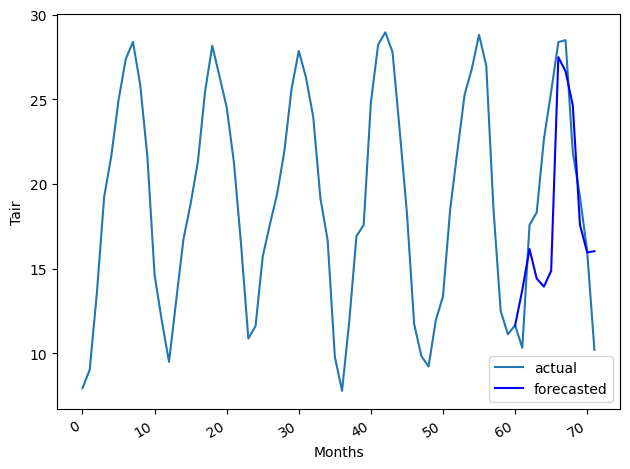

In [16]:
# Visualize predictions
fig, ax = plt.subplots()

# Plot actual data
ax.plot(df.Tair.tolist(), label='actual')

# Plot forecasted data with adjusted x-axis values
ax.plot(forecast_x_values, forecast_df.Tair, 'b-', label='forecasted')

ax.set_xlabel('Months')
ax.set_ylabel('Tair')
ax.legend()

fig.autofmt_xdate()
plt.tight_layout()

# Show the plot
plt.show()

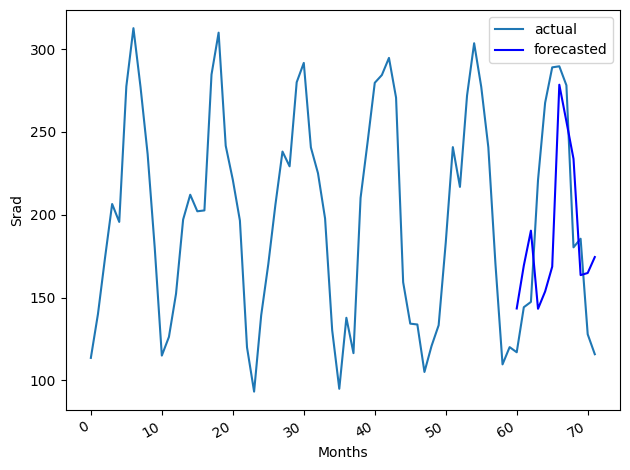

In [17]:
# Visualize predictions
fig, ax = plt.subplots()

# Plot actual data
ax.plot(df.Srad.tolist(), label='actual')

# Plot forecasted data with adjusted x-axis values
ax.plot(forecast_x_values, forecast_df.Srad, 'b-', label='forecasted')

ax.set_xlabel('Months')
ax.set_ylabel('Srad')
ax.legend()

fig.autofmt_xdate()
plt.tight_layout()

# Show the plot
plt.show()

In [18]:
mse_srad = mean_squared_error(forecast_df.Srad,df.Srad.tolist()[60:])
mse_srad

3782.1546656389874

In [19]:
mse_tair = mean_squared_error(forecast_df.Tair,df.Tair.tolist()[60:])
mse_tair

22.106373212032125